# Insurance 03 — Meaningful visuals, not icon counts
## Purpose
A document with many extracted pictures may contain no independent visual evidence. We inspect the actual Foyer IPID crops, retain a content review tied to their hashes, and compare them with a deliberately informative synthetic diagram.

Unknown pictures are held for review. Surrounding text no longer automatically qualifies an icon for Gemini. Charts/diagrams/tables are description candidates, not validated financial facts. Reviewed photos require a matching image hash.


In [1]:
from pathlib import Path
import sys, json, hashlib
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'backend/app').is_dir())
if str(ROOT / 'backend') not in sys.path:
    sys.path.insert(0, str(ROOT / 'backend'))
from IPython.display import display, Markdown, Image
import pandas as pd
BASE = ROOT / 'data/insurance_v2'
print('Isolated insurance workspace:', BASE)



Isolated insurance workspace: C:\Users\choun\Downloads\Prudential_Evidence_Lab_MVP_Source\prudential_evidence_lab\data\insurance_v2


## 1. Inspect the recorded content review
All nine PNG crops were visually inspected by the coding assistant. This is not a human expert validation or a benchmark of an automatic image classifier. Eight section pictograms and the logo are excluded as standalone evidence; their neighbouring text stays available.


,id,sha256,content
0,figure-001,efca55dbea105c7d259c291542cdd4a2f7cfb5ad61e394...,umbrella pictogram
1,figure-002,80877dc534269a62932e75929f7e2cc41c3df00c0d9ff4...,cross pictogram
2,figure-003,199ce4c4ed57bbaf98f2d0bae6e0fe22abf168dd471c91...,warning pictogram
3,figure-004,c4fbb6e21dc0376bcc0c8917541be90a798a53957dedb6...,Foyer logo
4,figure-005,2435f525b85089917d84a0a905f0bd3eba07a8318971a6...,globe pictogram
5,figure-006,d146bbf077a62ffe0b67c16f26c73f8ea8bcbb6141e07e...,handshake pictogram
6,figure-007,727ddea25f882ef60648dbf20337833af47cb5578e3a3c...,coins pictogram
7,figure-008,48da56c774f2423d049c76937a4e14c6135be4264f1e0b...,hourglass pictogram
8,figure-009,20f0ebc0c4f95d6129f7dac2e73bebf1b80aa3b1c03c99...,raised-hand pictogram


Assistant visually inspected all nine extracted PNG crops on 2026-09-24; not automatic semantic classification or human insurer validation.


**figure-001** — umbrella pictogram

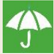

**figure-002** — cross pictogram

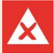

**figure-003** — warning pictogram

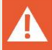

**figure-004** — Foyer logo

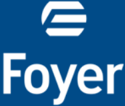

**figure-005** — globe pictogram

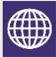

**figure-006** — handshake pictogram

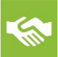

**figure-007** — coins pictogram

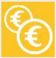

**figure-008** — hourglass pictogram

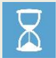

**figure-009** — raised-hand pictogram

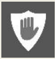

In [2]:
review = json.loads((ROOT / 'docs/insurance/visual_reviews.json').read_text())
display(pd.DataFrame(review['images']))
print(review['review_method'])
legacy_crops = ROOT / 'data/processed/insurance/foyer_mozaik_ipid_2021/figures'
if legacy_crops.is_dir():
    for item in review['images']:
        path = legacy_crops / (item['id'] + '.png')
        assert hashlib.sha256(path.read_bytes()).hexdigest() == item['sha256']
        display(Markdown('**' + item['id'] + '** — ' + item['content']))
        display(Image(filename=str(path)))
else:
    print('Optional historical Docling crops unavailable. The content review remains listed above.')


## 2. Test the enrichment gate
An unknown image with lots of nearby text must not pass. A cached description must not bypass exclusion. Photo relevance is contextual, not determined only by dimensions or file size.


In [3]:
from ingestion.models import FigureArtifact
from ingestion.visual_enrichment import should_enrich_visual
from ingestion.chunking import chunk_figures
icon = FigureArtifact(id='icon', page=1, preceding_text=['Important claim narrative'],
                      description={'factual_description': 'Cached but irrelevant'})
assert not should_enrich_visual(icon)
assert chunk_figures('fixture','Fixture',[icon],'Synthetic','2025') == []
display({'unknown_image': 'REVIEW_REQUIRED', 'description_calls': 0, 'evidence_chunks': 0})


{'unknown_image': 'REVIEW_REQUIRED',
 'description_calls': 0,
 'evidence_chunks': 0}

## 3. Inspect an informative visual fixture
The diagram has legible labels A=21%, B=12%, C=8% and room relationships. It is a synthetic extraction target, not a real damage photograph and not evidence that any particular peril occurred. We must not infer cause, repair cost, age or coverage from it.


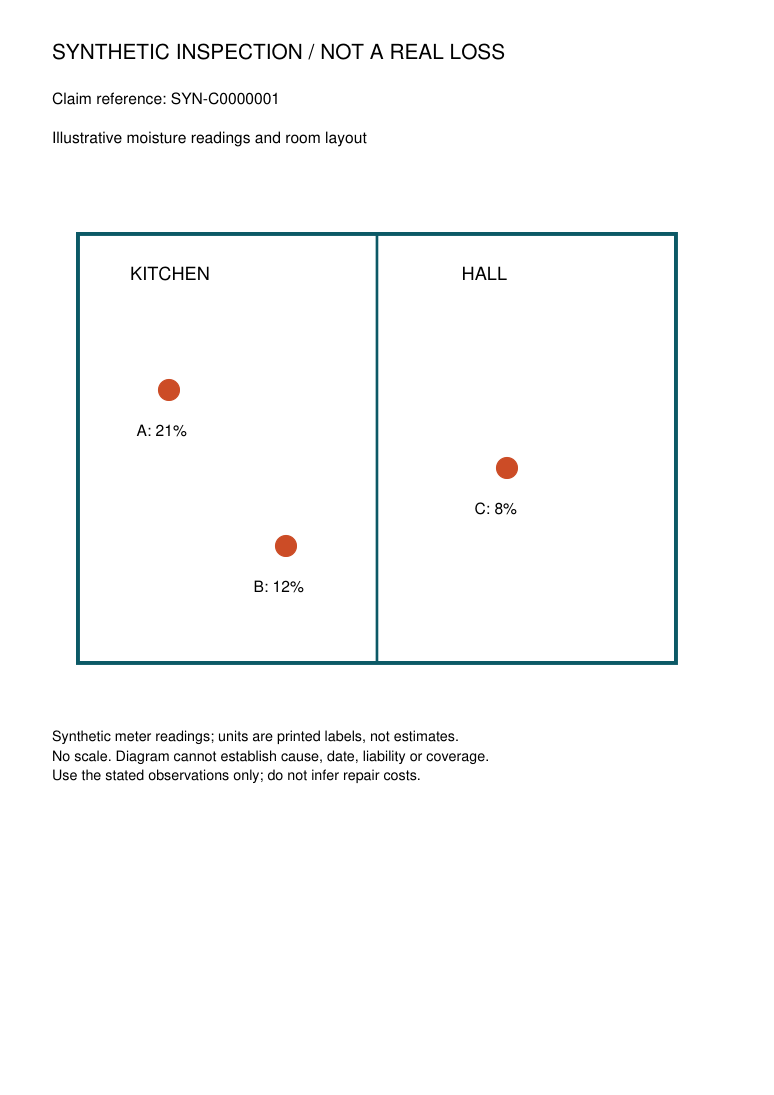

{'description_candidate': True,
 'financial_fact_verified': False,
 'expected_labels': ['A: 21%', 'B: 12%', 'C: 8%']}

In [4]:
from ingestion.insurance_dossiers import generate_dossiers
generate_dossiers(BASE / 'synthetic/dossiers')
path = BASE / 'synthetic/dossiers/D001_consistent/inspection_diagram.png'
display(Image(filename=str(path), width=650))
figure = FigureArtifact(id='synthetic-moisture-diagram', page=1, classification='diagram',
                        image_path=str(path), review_status='informative',
                        review_reason='Visible room labels and three printed synthetic readings',
                        review_image_sha256=hashlib.sha256(path.read_bytes()).hexdigest())
assert should_enrich_visual(figure)
display({'description_candidate': True, 'financial_fact_verified': False,
         'expected_labels': ['A: 21%', 'B: 12%', 'C: 8%']})


## 4. Optional Gemini experiment — off by default
Setting RUN_INSURANCE_VISUAL_EXPERIMENT=1 explicitly permits one paid call per execution, using GEMINI_API_KEY and GEMINI_GENERATION_MODEL from the environment. The generated output is displayed but never promoted to the live app. The local deterministic tests above do not establish Gemini extraction accuracy.


In [5]:
import os
if os.getenv('RUN_INSURANCE_VISUAL_EXPERIMENT') == '1':
    from dotenv import load_dotenv
    load_dotenv(ROOT / '.env')
    from ingestion.visual_enrichment import describe_with_gemini
    description = describe_with_gemini(figure)
    display(description.model_dump())
    print('Review labels, units and unsupported statements against the displayed image.')
else:
    print('NOT RUN: paid Gemini visual extraction. No accuracy score is claimed.')


NOT RUN: paid Gemini visual extraction. No accuracy score is claimed.


## Interpretation
Excluding icons reduces wasted description calls and irrelevant chunks; it is not proof of a retrieval-quality gain. Unknown visuals require review rather than being declared useless. A changed reviewed image invalidates its approval. Source-PDF provenance and statement-level verification are still needed before any production promotion.
